In [2]:
from virginia_zip_population import download_zcta_dhc
from process_census import process_va_zctas

In [3]:
download_zcta_dhc()

Connecting to Census API...
URL: https://api.census.gov/data/2020/dec/dhc
HTTP 200 — 1,066,710 bytes received
Saved raw JSON: census_data/zcta_dhc_2020_raw.json
Saved CSV:      census_data/zcta_dhc_2020.csv  (33,774 ZCTAs)

Download complete.


'census_data/zcta_dhc_2020.csv'

In [4]:
process_va_zctas()

Loaded 33,774 total ZCTAs from census_data/zcta_dhc_2020.csv
Found 903 Virginia ZCTAs
Total VA population (sum of ZCTAs): 3,618,352
Saved: census_data/va_zcta_dhc_2020.csv

--- First 10 Virginia ZCTAs ---
       name  population  zcta
ZCTA5 20105       10189 20105
ZCTA5 20106        1855 20106
ZCTA5 20109       15317 20109
ZCTA5 20110       16061 20110
ZCTA5 20111       12228 20111
ZCTA5 20112        9374 20112
ZCTA5 20115        2780 20115
ZCTA5 20117        1479 20117
ZCTA5 20119        1596 20119
ZCTA5 20120       14867 20120


,name,population,zcta
0,ZCTA5 20105,10189,20105
1,ZCTA5 20106,1855,20106
2,ZCTA5 20109,15317,20109
3,ZCTA5 20110,16061,20110
4,ZCTA5 20111,12228,20111
...,...,...,...
898,ZCTA5 24646,324,24646
899,ZCTA5 24649,1118,24649
900,ZCTA5 24651,2878,24651
901,ZCTA5 24656,1555,24656


In [7]:
# Psychology Today therapist count lookup by ZIP code.
# Extracts 'results_total' directly from the embedded JSON in the page.
# This is far more reliable than parsing rendered HTML.
# Compatible with Python 3.7+

import requests
from bs4 import BeautifulSoup
import csv
import re
import time
import random
import sys
import json
from pathlib import Path
from urllib.parse import urlencode


# ---------- Configuration ----------
BASE_URL = "https://www.psychologytoday.com/us/therapists"
OUTPUT_DIR = Path("therapist_counts")
OUTPUT_CSV = OUTPUT_DIR / "therapist_counts_by_zip.csv"
HTML_CACHE_DIR = OUTPUT_DIR / "html_cache"

MIN_DELAY = 4.0
MAX_DELAY = 8.0
REQUEST_TIMEOUT = 30

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
}

# Regex to find 'results_total': 963  (or "results_total":963 etc.)
# Tolerates whitespace and either single/double quotes around the key.
RESULTS_TOTAL_PATTERN = re.compile(
    r'["\']?results_total["\']?\s*:\s*(\d+)'
)


# ---------- Core extraction ----------
def extract_results_total(html_text):
    """
    Extract the 'results_total' integer from the page HTML.
    Returns int or None.
    
    Strategy: Find ALL matches of the pattern. If they all agree, return that
    value. If they disagree, return the largest (heuristic: the page-level
    total is usually the biggest number among any nested counts).
    """
    matches = RESULTS_TOTAL_PATTERN.findall(html_text)
    if not matches:
        return None
    
    # Convert all matches to integers
    values = [int(v) for v in matches]
    
    # If all agree, use that value
    if len(set(values)) == 1:
        return values[0]
    
    # Otherwise return the maximum (typically the directory-wide total)
    return max(values)


# ---------- Fetch one ZIP ----------
def fetch_zip(zip_code, session, save_html=True):
    """
    Fetches Psychology Today search page for one ZIP and extracts results_total.
    """
    url = "{}?{}".format(BASE_URL, urlencode({"search": zip_code}))
    
    result = {
        "zip": zip_code,
        "url": url,
        "http_status": None,
        "results_total": None,
        "all_matches": None,    # for debugging — every value found
        "error": None,
    }
    
    try:
        resp = session.get(url, headers=HEADERS, timeout=REQUEST_TIMEOUT)
        result["http_status"] = resp.status_code
        
        if resp.status_code in (403, 429, 503):
            result["error"] = "Likely blocked or rate-limited (HTTP {})".format(
                resp.status_code
            )
            return result
        
        resp.raise_for_status()
        
        # Save raw HTML for offline re-parsing / audit
        if save_html:
            HTML_CACHE_DIR.mkdir(parents=True, exist_ok=True)
            (HTML_CACHE_DIR / "{}.html".format(zip_code)).write_text(
                resp.text, encoding="utf-8"
            )
        
        # Find ALL results_total values for transparency
        all_values = [int(v) for v in RESULTS_TOTAL_PATTERN.findall(resp.text)]
        result["all_matches"] = ",".join(str(v) for v in all_values) if all_values else None
        
        # Pick the canonical value
        result["results_total"] = extract_results_total(resp.text)
        
        if result["results_total"] is None:
            result["error"] = "results_total not found in page HTML"
        
    except requests.exceptions.RequestException as e:
        result["error"] = "Request error: {}".format(e)
    except Exception as e:
        result["error"] = "Parse error: {}".format(e)
    
    return result


# ---------- Re-parse from cached HTML (no network needed) ----------
def reparse_cached(zip_code):
    """
    Re-extract results_total from a previously cached HTML file.
    Useful for re-running analysis without hitting the site again.
    """
    html_file = HTML_CACHE_DIR / "{}.html".format(zip_code)
    if not html_file.exists():
        return None
    html = html_file.read_text(encoding="utf-8")
    return extract_results_total(html)


# ---------- Batch driver ----------
def lookup_zips(zip_codes):
    """
    Iterates over ZIP codes with polite delays.
    """
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    results = []
    
    with requests.Session() as session:
        for i, zc in enumerate(zip_codes, start=1):
            print("[{}/{}] ZIP {}...".format(i, len(zip_codes), zc), end=" ")
            sys.stdout.flush()
            
            res = fetch_zip(zc, session)
            results.append(res)
            
            if res["error"]:
                print("ERROR: {}".format(res["error"]))
            else:
                print("results_total = {} (all matches: {})".format(
                    res["results_total"], res["all_matches"]
                ))
            
            if i < len(zip_codes):
                time.sleep(random.uniform(MIN_DELAY, MAX_DELAY))
    
    return results


def save_results(results, path=OUTPUT_CSV):
    """
    Saves results to CSV.
    """
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "zip", "results_total", "all_matches",
        "http_status", "url", "error"
    ]
    with open(str(path), "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)
    print("\nSaved {} rows to {}".format(len(results), path))


# ---------- Entry point ----------
if __name__ == "__main__":
    test_zips = [
        "22102",  # McLean
        "22030",  # Fairfax
        "22201",  # Arlington
        "20120",  # Centreville
        "22310",  # Alexandria
    ]
    
    print("Looking up {} ZIP codes\n".format(len(test_zips)))
    results = lookup_zips(test_zips)
    save_results(results)
    
    # Summary
    successful = [r for r in results if r["results_total"] is not None]
    failed = [r for r in results if r["results_total"] is None]
    
    print("\n--- Summary ---")
    print("Successful: {}/{}".format(len(successful), len(results)))
    print("Failed:     {}/{}".format(len(failed), len(results)))
    if successful:
        total = sum(r["results_total"] for r in successful)
        avg = total / len(successful)
        print("Total therapists across all ZIPs: {:,}".format(total))
        print("Average per ZIP: {:.1f}".format(avg))

Looking up 5 ZIP codes

[1/5] ZIP 22102... ERROR: results_total not found in page HTML
[2/5] ZIP 22030... ERROR: results_total not found in page HTML
[3/5] ZIP 22201... ERROR: results_total not found in page HTML
[4/5] ZIP 20120... ERROR: results_total not found in page HTML
[5/5] ZIP 22310... ERROR: results_total not found in page HTML

Saved 5 rows to therapist_counts/therapist_counts_by_zip.csv

--- Summary ---
Successful: 0/5
Failed:     5/5


In [16]:
# Psychology Today therapist count lookup by ZIP code.
# Extracts 'resultCount' from the embedded dataLayer JSON in the page HTML.
# FIXED: Removed all &lt; and &gt; format specifiers — uses .ljust()/.rjust() instead.
# Compatible with Python 3.7+

import requests
import csv
import re
import time
import random
import sys
from pathlib import Path
from urllib.parse import urlencode


# ---------- Configuration ----------
BASE_URL = "https://www.psychologytoday.com/us/therapists"
OUTPUT_DIR = Path("therapist_counts")
OUTPUT_CSV = OUTPUT_DIR / "therapist_counts_by_zip.csv"
HTML_CACHE_DIR = OUTPUT_DIR / "html_cache"

MIN_DELAY = 4.0
MAX_DELAY = 8.0
REQUEST_TIMEOUT = 30

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
}

# Precise regex patterns targeting the dataLayer push block
RESULT_COUNT_PATTERN   = re.compile(r'"resultCount"\s*:\s*(\d+)')
NEARBY_COUNT_PATTERN   = re.compile(r'"nearbyResultCount"\s*:\s*(\d+)')
TELE_COUNT_PATTERN     = re.compile(r'"teletherapyExpandedCount"\s*:\s*(\d+)')
POSTAL_CODE_PATTERN    = re.compile(r'"postalCode"\s*:\s*"(\d+)"')
REGION_PATTERN         = re.compile(r'"regionName"\s*:\s*"([^"]+)"')


# ---------- Helpers ----------
def safe_str(val, width=0, align="left"):
    """
    Safely convert val to string. Optionally pad to width.
    align: 'left' uses ljust, 'right' uses rjust.
    Avoids all &lt; and &gt; inside format strings.
    """
    s = str(val) if val is not None else "N/A"
    if width > 0:
        if align == "right":
            return s.rjust(width)
        return s.ljust(width)
    return s


def safe_int(match_obj):
    """
    Return int from a regex match group(1), or None if no match.
    """
    if match_obj:
        try:
            return int(match_obj.group(1))
        except ValueError:
            return None
    return None


# ---------- Core extraction ----------
def extract_data_from_html(html_text, zip_code):
    """
    Extracts resultCount and supporting metadata from the embedded
    dataLayer JSON block in the Psychology Today page HTML.
    Returns a dict with all extracted fields.
    """
    result = {
        "result_count":         safe_int(RESULT_COUNT_PATTERN.search(html_text)),
        "nearby_result_count":  safe_int(NEARBY_COUNT_PATTERN.search(html_text)),
        "teletherapy_count":    safe_int(TELE_COUNT_PATTERN.search(html_text)),
        "resolved_postal_code": None,
        "resolved_region":      None,
        "zip_mismatch":         False,
        "extraction_ok":        False,
    }

    # Mark extraction as successful only if we got the primary count
    if result["result_count"] is not None:
        result["extraction_ok"] = True

    # Resolved postal code
    m = POSTAL_CODE_PATTERN.search(html_text)
    if m:
        result["resolved_postal_code"] = m.group(1)
        result["zip_mismatch"] = (result["resolved_postal_code"] != zip_code)

    # Resolved region name
    m = REGION_PATTERN.search(html_text)
    if m:
        result["resolved_region"] = m.group(1)

    return result


# ---------- Fetch one ZIP ----------
def fetch_zip(zip_code, session, save_html=True):
    """
    Fetches the Psychology Today search page for one ZIP code,
    saves the HTML, and extracts resultCount from the dataLayer block.
    """
    url = "{}?{}".format(BASE_URL, urlencode({"search": zip_code}))

    result = {
        "zip":                  zip_code,
        "url":                  url,
        "http_status":          None,
        "result_count":         None,
        "nearby_result_count":  None,
        "teletherapy_count":    None,
        "resolved_postal_code": None,
        "resolved_region":      None,
        "zip_mismatch":         False,
        "error":                None,
    }

    try:
        resp = session.get(url, headers=HEADERS, timeout=REQUEST_TIMEOUT)
        result["http_status"] = resp.status_code

        # Detect bot blocking
        if resp.status_code in (403, 429, 503):
            result["error"] = "Likely blocked or rate-limited (HTTP {})".format(
                resp.status_code
            )
            return result

        resp.raise_for_status()

        # Save raw HTML to cache
        if save_html:
            HTML_CACHE_DIR.mkdir(parents=True, exist_ok=True)
            cache_path = HTML_CACHE_DIR / "{}.html".format(zip_code)
            cache_path.write_text(resp.text, encoding="utf-8")

        # Extract all fields from HTML
        extracted = extract_data_from_html(resp.text, zip_code)
        result.update(extracted)

        if not extracted["extraction_ok"]:
            result["error"] = (
                "resultCount not found. "
                "Site may have changed or returned a bot-challenge page."
            )

    except requests.exceptions.RequestException as e:
        result["error"] = "Request error: {}".format(e)
    except Exception as e:
        result["error"] = "Parse error: {}".format(e)

    return result


# ---------- Re-parse all cached HTML offline ----------
def reparse_all_cached():
    """
    Re-extracts counts from all cached HTML files with no network calls.
    Useful when extraction logic changes without needing to re-fetch.
    """
    results = []
    html_files = sorted(HTML_CACHE_DIR.glob("*.html"))

    if not html_files:
        print("No cached HTML files found in {}".format(HTML_CACHE_DIR))
        return results

    print("Re-parsing {} cached HTML files...".format(len(html_files)))

    for html_file in html_files:
        zip_code = html_file.stem
        html = html_file.read_text(encoding="utf-8")
        extracted = extract_data_from_html(html, zip_code)

        row = {"zip": zip_code}
        row.update(extracted)
        results.append(row)

        status = "OK  " if extracted["extraction_ok"] else "MISS"
        print("  {} {}  resultCount = {}  region = {}".format(
            status,
            safe_str(zip_code, width=6),
            safe_str(extracted["result_count"], width=6, align="right"),
            safe_str(extracted["resolved_region"]),
        ))

    return results


# ---------- Batch driver ----------
def lookup_zips(zip_codes, use_cache_if_available=True):
    """
    Iterates over ZIP codes with polite delays.
    Uses cached HTML if available to avoid re-hitting the site.
    """
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    results = []

    with requests.Session() as session:
        for i, zc in enumerate(zip_codes, start=1):

            cache_file = HTML_CACHE_DIR / "{}.html".format(zc)

            # Use cache if available and requested
            if use_cache_if_available and cache_file.exists():
                print("[{}/{}] ZIP {} (from cache)...".format(
                    i, len(zip_codes), zc
                ), end=" ")
                html = cache_file.read_text(encoding="utf-8")
                extracted = extract_data_from_html(html, zc)
                res = {"zip": zc, "url": "(cached)", "http_status": "(cached)"}
                res.update(extracted)
                res["error"] = (
                    None if extracted["extraction_ok"] else "resultCount not found"
                )
            else:
                print("[{}/{}] ZIP {} (live fetch)...".format(
                    i, len(zip_codes), zc
                ), end=" ")
                res = fetch_zip(zc, session)

            results.append(res)
            sys.stdout.flush()

            # Print result row — no &lt; or &gt; used anywhere
            if res.get("error"):
                print("ERROR: {}".format(res["error"]))
            else:
                mismatch_flag = ""
                if res.get("zip_mismatch"):
                    mismatch_flag = " [MISMATCH to {}]".format(
                        res.get("resolved_postal_code")
                    )
                print(
                    "resultCount = {}  nearby = {}  tele = {}  region = {}{}".format(
                        safe_str(res.get("result_count"),        width=6, align="right"),
                        safe_str(res.get("nearby_result_count"), width=5, align="right"),
                        safe_str(res.get("teletherapy_count"),   width=5, align="right"),
                        safe_str(res.get("resolved_region")),
                        mismatch_flag,
                    )
                )

            # Polite delay between live fetches
            if i < len(zip_codes) and not (use_cache_if_available and cache_file.exists()):
                time.sleep(random.uniform(MIN_DELAY, MAX_DELAY))

    return results


# ---------- Save to CSV ----------
def save_results(results, path=OUTPUT_CSV):
    """
    Saves results list to CSV. Uses extrasaction='ignore' to handle
    any extra keys gracefully.
    """
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "zip",
        "result_count",
        "nearby_result_count",
        "teletherapy_count",
        "resolved_postal_code",
        "resolved_region",
        "zip_mismatch",
        "http_status",
        "url",
        "error",
    ]
    with open(str(path), "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(results)
    print("\nSaved {} rows to {}".format(len(results), path))


# ---------- Entry point ----------
if __name__ == "__main__":
    test_zips = [
        "22102",  # McLean
        "22030",  # Fairfax
        "22201",  # Arlington
        "20120",  # Centreville
        "22310",  # Alexandria
    ]

    print("Looking up {} ZIP codes\n".format(len(test_zips)))

    results = lookup_zips(test_zips, use_cache_if_available=True)
    save_results(results)

    # Summary stats — no &lt; or &gt; used
    good       = [r for r in results if r.get("result_count") is not None]
    mismatches = [r for r in results if r.get("zip_mismatch")]
    failed     = [r for r in results if r.get("result_count") is None]

    print("\n--- Summary ---")
    print("ZIPs with count  : {}/{}".format(len(good), len(results)))
    print("ZIP mismatches   : {}".format(len(mismatches)))
    print("Failed / no data : {}".format(len(failed)))
    if good:
        counts = [r["result_count"] for r in good]
        print("Total therapists : {}".format(sum(counts)))
        print("Average per ZIP  : {}".format(round(sum(counts) / len(counts), 1)))
        print("Min count        : {}".format(min(counts)))
        print("Max count        : {}".format(max(counts)))

Looking up 5 ZIP codes

[1/5] ZIP 22102 (from cache)... resultCount =    246  nearby =     0  tele =     0  region = Virginia
[2/5] ZIP 22030 (from cache)... resultCount =    963  nearby =     0  tele =     0  region = Virginia
[3/5] ZIP 22201 (from cache)... resultCount =    638  nearby =     0  tele =     0  region = Virginia
[4/5] ZIP 20120 (from cache)... resultCount =     91  nearby =     0  tele =     0  region = Virginia
[5/5] ZIP 22310 (from cache)... resultCount =    108  nearby =     0  tele =     0  region = Virginia

Saved 5 rows to therapist_counts/therapist_counts_by_zip.csv

--- Summary ---
ZIPs with count  : 5/5
ZIP mismatches   : 0
Failed / no data : 0
Total therapists : 2046
Average per ZIP  : 409.2
Min count        : 91
Max count        : 963


In [8]:
https://www.psychologytoday.com/directory-listing/metrics/page

SyntaxError: invalid syntax (1618994768.py, line 1)

In [45]:
# Batch driver for Psychology Today therapist counts.
# Calls the existing fetch_zip() function across large ZIP ranges with:
#   - Resume capability (skips ZIPs already in output CSV)
#   - Append-as-you-go writing (never lose progress)
#   - Progress reporting with ETA
#   - Optional pre-filtering to real ZIPs only
#   - Adaptive backoff on errors
#
# Save in same folder as pt_pull_therapist_counts.py

import requests
import csv
import time
import random
import sys
from pathlib import Path
from datetime import datetime, timedelta

# Import functions from your existing script
from pt_pull_therapist_counts import (
    fetch_zip,
    HEADERS,
    HTML_CACHE_DIR,
    OUTPUT_DIR,
    MIN_DELAY,
    MAX_DELAY,
)

# ---------- Configuration ----------
OUTPUT_CSV = OUTPUT_DIR / "therapist_counts_by_zip.csv"
ERROR_LOG = OUTPUT_DIR / "errors.log"

# ZIP ranges to process (inclusive)
ZIP_RANGES = [
    (20101, 20199),   # Loudoun County / parts of NoVA
    (22001, 24699),   # Bulk of Virginia
]

# NEW:
REAL_ZIPS_CSV = Path("./census_data/va_zcta_dhc_2020.csv")
# REAL_ZIPS_COLUMN no longer used — we read the last column by position

# Adaptive backoff thresholds
ERROR_BACKOFF_MULTIPLIER = 2.0    # double delays after errors
MAX_CONSECUTIVE_ERRORS = 100      # stop if this many errors in a row

# CSV columns (must match what fetch_zip returns)
FIELDNAMES = [
    "zip",
    "result_count",
    "nearby_result_count",
    "teletherapy_count",
    "resolved_postal_code",
    "resolved_region",
    "zip_mismatch",
    "http_status",
    "url",
    "error",
]


# ---------- Build the ZIP list ----------
def build_zip_list():
    """
    Build the full list of ZIP codes to process from configured ranges,
    optionally filtered against a real-ZIPs CSV (uses the LAST column).
    """
    all_zips = []
    for start, end in ZIP_RANGES:
        for n in range(start, end + 1):
            all_zips.append("{:05d}".format(n))

    print("Generated {} ZIP codes from ranges".format(len(all_zips)))
    print(REAL_ZIPS_CSV)

    # Optional filter to real ZIPs — read LAST column of the CSV
    if REAL_ZIPS_CSV and Path(REAL_ZIPS_CSV).exists():
        real = set()
        with open(str(REAL_ZIPS_CSV), "r", encoding="utf-8") as f:
            reader = csv.reader(f)
            next(reader, None)   # skip header row
            for row in reader:
                if not row:
                    continue
                z = row[-1].strip().zfill(5)   # LAST column
                if z:
                    real.add(z)
        before = len(all_zips)
        all_zips = [z for z in all_zips if z in real]
        print("Filtered to {} real ZIPs (removed {})".format(
            len(all_zips), before - len(all_zips)
        ))

    return all_zips

# ---------- Resume support ----------
def load_completed_zips():
    """
    Load the set of ZIPs already in the output CSV so we can resume.
    """
    if not OUTPUT_CSV.exists():
        return set()
    completed = set()
    with open(str(OUTPUT_CSV), "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            zc = row.get("zip", "").strip()
            if zc:
                completed.add(zc)
    return completed


def init_csv_if_needed():
    """
    Create the CSV with headers if it doesn't exist yet.
    """
    if not OUTPUT_CSV.exists():
        OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
        with open(str(OUTPUT_CSV), "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=FIELDNAMES, extrasaction="ignore")
            writer.writeheader()
        print("Created new output CSV: {}".format(OUTPUT_CSV))


def append_row(row):
    """
    Append a single row to the output CSV. Flushes immediately so progress
    is preserved if the script is killed.
    """
    with open(str(OUTPUT_CSV), "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES, extrasaction="ignore")
        writer.writerow(row)


def log_error(zip_code, message):
    """
    Append an error line to the error log.
    """
    with open(str(ERROR_LOG), "a", encoding="utf-8") as f:
        f.write("{} ZIP {} : {}\n".format(
            datetime.now().isoformat(timespec="seconds"),
            zip_code,
            message,
        ))


# ---------- Progress reporting ----------
def format_eta(seconds):
    """
    Format seconds as H:MM:SS.
    """
    return str(timedelta(seconds=int(seconds)))


def print_progress(idx, total, start_time, current_delay, error_count):
    """
    Print a progress line with ETA.
    """
    elapsed = time.time() - start_time
    rate = idx / elapsed if elapsed > 0 else 0
    remaining = (total - idx) / rate if rate > 0 else 0
    print(
        "  Progress: {}/{} ({}%) | elapsed {} | ETA {} | delay {}s | errors {}".format(
            idx,
            total,
            round(100 * idx / total, 1),
            format_eta(elapsed),
            format_eta(remaining),
            round(current_delay, 1),
            error_count,
        )
    )


# ---------- Main batch loop ----------
def run_batch():
    """
    Main batch processor with resume, append, and adaptive backoff.
    """
    # Build ZIP list
    all_zips = build_zip_list()

    # Initialize CSV and load completed
    init_csv_if_needed()
    completed = load_completed_zips()
    print("Already completed: {} ZIPs (will skip)".format(len(completed)))

    # Filter out completed
    todo = [z for z in all_zips if z not in completed]
    print("ZIPs to process this run: {}".format(len(todo)))
    print("Estimated time at {}-{}s/ZIP: {} to {}".format(
        MIN_DELAY,
        MAX_DELAY,
        format_eta(len(todo) * MIN_DELAY),
        format_eta(len(todo) * MAX_DELAY),
    ))

    if not todo:
        print("\nNothing to do. All ZIPs already processed.")
        return

    # Confirm with user before starting a long run
    if len(todo) > 100:
        print("\n!! WARNING: This will make {} live HTTP requests.".format(len(todo)))
        print("!! Press Ctrl+C now to abort, or wait 10 seconds to continue...")
        try:
            time.sleep(10)
        except KeyboardInterrupt:
            print("\nAborted by user.")
            return

    print("\nStarting batch at {}\n".format(
        datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    ))

    # Process loop
    start_time = time.time()
    consecutive_errors = 0
    total_errors = 0
    current_min_delay = MIN_DELAY
    current_max_delay = MAX_DELAY

    with requests.Session() as session:
        for i, zc in enumerate(todo, start=1):
            print("[{}/{}] ZIP {}...".format(i, len(todo), zc), end=" ")
            sys.stdout.flush()

            # Fetch
            try:
                row = fetch_zip(zc, session, save_html=True)
            except Exception as e:
                row = {
                    "zip": zc,
                    "url": "",
                    "http_status": None,
                    "result_count": None,
                    "nearby_result_count": None,
                    "teletherapy_count": None,
                    "resolved_postal_code": None,
                    "resolved_region": None,
                    "zip_mismatch": False,
                    "error": "Unhandled exception: {}".format(e),
                }

            # Append immediately so progress is preserved
            append_row(row)

            # Report and track errors
            if row.get("error"):
                consecutive_errors += 1
                total_errors += 1
                log_error(zc, row["error"])
                print("ERROR: {}".format(row["error"]))

                # Stop if we hit too many consecutive errors
                if consecutive_errors >= MAX_CONSECUTIVE_ERRORS:
                    print("\n!! {} consecutive errors. Stopping to avoid further issues.".format(
                        consecutive_errors
                    ))
                    print("!! Re-run the script to resume from this point.")
                    break

                # Adaptive backoff
                current_min_delay = min(MIN_DELAY * ERROR_BACKOFF_MULTIPLIER, 30)
                current_max_delay = min(MAX_DELAY * ERROR_BACKOFF_MULTIPLIER, 60)
            else:
                # Reset on success — gradually return to normal delay
                consecutive_errors = 0
                current_min_delay = MIN_DELAY
                current_max_delay = MAX_DELAY
                print("resultCount = {} | region = {}".format(
                    row.get("result_count"),
                    row.get("resolved_region"),
                ))

            # Progress every 25 ZIPs
            if i % 25 == 0:
                print_progress(i, len(todo), start_time,
                               (current_min_delay + current_max_delay) / 2,
                               total_errors)

            # Sleep between requests (skip on last)
            if i < len(todo):
                time.sleep(random.uniform(current_min_delay, current_max_delay))

    # Final summary
    elapsed = time.time() - start_time
    print("\n" + "=" * 60)
    print("Batch complete.")
    print("Elapsed time : {}".format(format_eta(elapsed)))
    print("Total errors : {}".format(total_errors))
    print("Output CSV   : {}".format(OUTPUT_CSV))
    print("Error log    : {}".format(ERROR_LOG))


# ---------- Entry point ----------
if __name__ == "__main__":
    run_batch()

Generated 2798 ZIP codes from ranges
census_data/va_zcta_dhc_2020.csv
Filtered to 903 real ZIPs (removed 1895)
Already completed: 1260 ZIPs (will skip)
ZIPs to process this run: 0
Estimated time at 4.0-8.0s/ZIP: 0:00:00 to 0:00:00

Nothing to do. All ZIPs already processed.


In [47]:
import csv
from pathlib import Path

# ---------- Configuration ----------
CENSUS_CSV     = Path("census_data/virginia-zip-codes.csv")
THERAPIST_CSV  = Path("therapist_counts/therapist_counts_by_zip.csv")
OUTPUT_CSV     = Path("combined_zip_population_therapists.csv")

# ---------- Region label rubric ----------
REGION_RULES = [
    (201, 201, "Northern VA - North/West"),
    (220, 220, "Northern VA - Central NoVA"),
    (221, 221, "Northern VA - East/Central"),
    (222, 222, "Northern VA - Arlington"),
    (223, 223, "Northern VA - Alexandria"),
    (230, 232, "Central/East VA - Richmond Area"),
    (233, 235, "Central/East VA - Hampton Roads/Tidewater"),
    (236, 237, "Central/East VA - Peninsula/Hampton Roads"),
    (238, 239, "Central/East VA - Southside/Central"),
    (240, 241, "Western/SW VA - Roanoke Area"),
    (242, 242, "Western/SW VA - Far Southwest"),
    (243, 244, "Western/SW VA - Mountain Region"),
    (245, 245, "Western/SW VA - Southern/Piedmont"),
]

def label_zip(zip_code):
    try:
        prefix = int(zip_code[:3])
    except (ValueError, TypeError):
        return "Other"
    for low, high, label in REGION_RULES:
        if low <= prefix <= high:
            return label
    return "Other"

# ---------- Load Census population data ----------
def load_population():
    """
    Reads census_data/virginia-zip-codes.csv and returns a dict:
        { zip_string : population_int }
    The header is:
        "zip","city","county","population"
    """
    pop = {}
    with open(str(CENSUS_CSV), "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        skipped_blank = 0
        for row in reader:
            zip_raw = (row.get("zip") or "").strip()
            if not zip_raw:
                skipped_blank += 1
                continue
            zip_code = zip_raw.zfill(5)
            try:
                population = int(row.get("population", "0").strip())
            except ValueError:
                population = 0
            pop[zip_code] = population
    print("Loaded population data for {} ZIPs ({} blank rows skipped)".format(
        len(pop), skipped_blank
    ))
    return pop

# ---------- Load therapist counts ----------
def load_therapist_counts():
    counts = {}
    skipped_error = 0
    skipped_blank = 0
    with open(str(THERAPIST_CSV), "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            zip_raw = (row.get("zip") or "").strip()
            if not zip_raw:
                skipped_blank += 1
                continue
            zip_code = zip_raw.zfill(5)
            error = (row.get("error") or "").strip()
            if error:
                skipped_error += 1
                continue
            count_raw = (row.get("result_count") or "").strip()
            if not count_raw:
                skipped_blank += 1
                continue
            try:
                count = int(count_raw)
            except ValueError:
                skipped_blank += 1
                continue
            counts[zip_code] = count
    print("Loaded therapist counts for {} ZIPs".format(len(counts)))
    print("  Skipped due to error  : {}".format(skipped_error))
    print("  Skipped blank/invalid : {}".format(skipped_blank))
    return counts

# ---------- Combine and write output ----------
def combine_and_write(population, counts):
    rows_out = []
    matched = 0
    skipped_no_pop_match = 0
    skipped_no_count_match = 0
    skipped_zero_pop = 0
    all_zips = set(counts.keys()) | set(population.keys())
    for zip_code in sorted(all_zips):
        count = counts.get(zip_code)
        pop = population.get(zip_code)
        if count is None:
            skipped_no_count_match += 1
            continue
        if pop is None:
            skipped_no_pop_match += 1
            continue
        if pop == 0:
            skipped_zero_pop += 1
            continue
        density = (count / pop) * 10000.0
        region = label_zip(zip_code)
        rows_out.append({
            "Zip":        zip_code,
            "Population": pop,
            "Count":      count,
            "Density":    round(density, 4),
            "Region":     region,
        })
        matched += 1
    OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = ["Zip", "Population", "Count", "Density", "Region"]
    with open(str(OUTPUT_CSV), "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows_out)
    print("\n--- Join Summary ---")
    print("Matched (in output)         : {}".format(matched))
    print("Therapist ZIPs not in Census: {}".format(skipped_no_pop_match))
    print("Census ZIPs not in counts   : {}".format(skipped_no_count_match))
    print("Dropped zero-population     : {}".format(skipped_zero_pop))
    print("\nWrote {} rows to {}".format(matched, OUTPUT_CSV))
    total_population = sum(row["Population"] for row in rows_out)
    print("Total population of all ZIP codes in output: {:,}".format(total_population))
    return total_population

def print_region_summary():
    if not OUTPUT_CSV.exists():
        return
    by_region = {}
    with open(str(OUTPUT_CSV), "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            r = row["Region"]
            by_region.setdefault(r, {"zips": 0, "pop": 0, "count": 0})
            by_region[r]["zips"]  += 1
            by_region[r]["pop"]   += int(row["Population"])
            by_region[r]["count"] += int(row["Count"])
    print("\n--- Summary by Region ---")
    print("{:50s} {:>6s} {:>12s} {:>10s} {:>10s}".format(
        "Region", "ZIPs", "Population", "Therapists", "Density"
    ))
    print("-" * 92)
    for region in sorted(by_region.keys()):
        d = by_region[region]
        density = (d["count"] / d["pop"] * 10000.0) if d["pop"] else 0
        print("{:50s} {:>6d} {:>12,d} {:>10,d} {:>10.2f}".format(
            region, d["zips"], d["pop"], d["count"], density
        ))

if __name__ == "__main__":
    print("Loading Census population data...")
    population = load_population()
    print("\nLoading therapist counts...")
    counts = load_therapist_counts()
    print("\nJoining datasets...")
    combine_and_write(population, counts)
    print_region_summary()

Loading Census population data...
Loaded population data for 903 ZIPs (0 blank rows skipped)

Loading therapist counts...
Loaded therapist counts for 1039 ZIPs
  Skipped due to error  : 221
  Skipped blank/invalid : 0

Joining datasets...

--- Join Summary ---
Matched (in output)         : 886
Therapist ZIPs not in Census: 136
Census ZIPs not in counts   : 0
Dropped zero-population     : 17

Wrote 886 rows to combined_zip_population_therapists.csv
Total population of all ZIP codes in output: 8,705,380

--- Summary by Region ---
Region                                               ZIPs   Population Therapists    Density
--------------------------------------------------------------------------------------------
Central/East VA - Hampton Roads/Tidewater              86    1,123,884      3,874      34.47
Central/East VA - Peninsula/Hampton Roads              29      487,522      1,122      23.01
Central/East VA - Richmond Area                       114    1,270,931      5,477      43.09
C

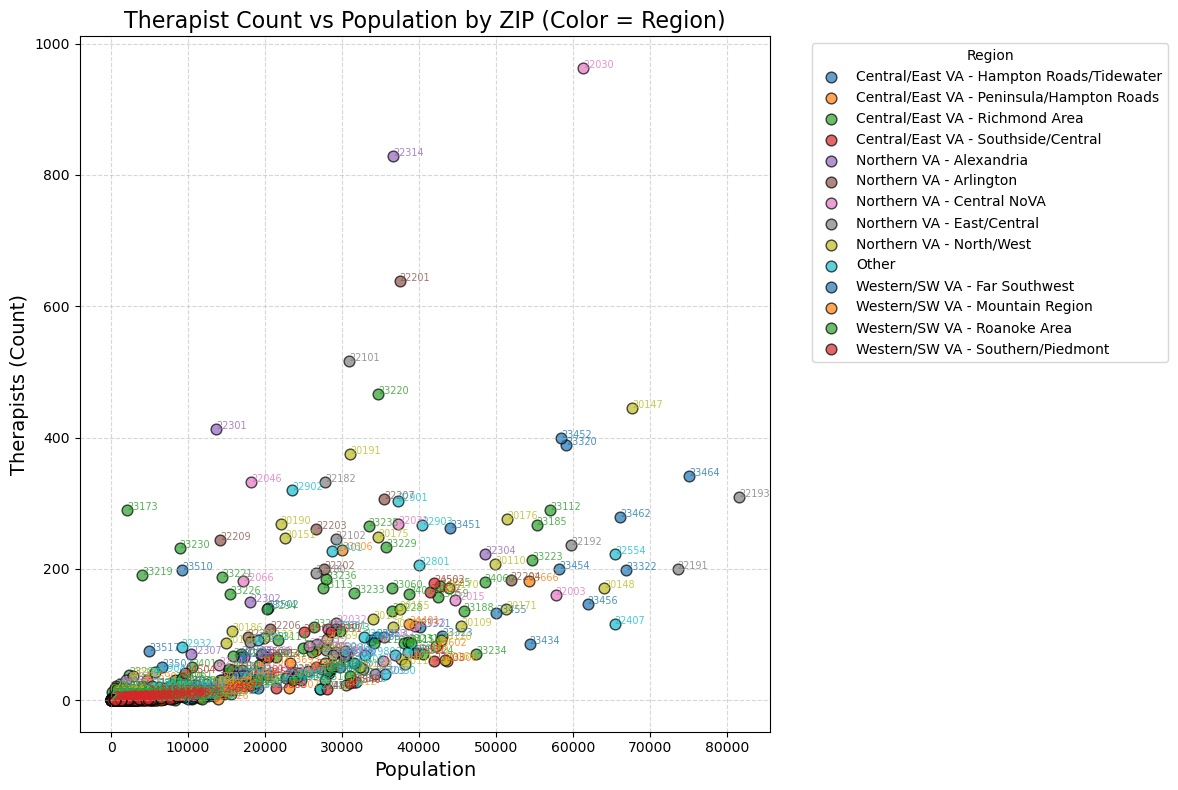

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Load your combined CSV
df = pd.read_csv("combined_zip_population_therapists.csv")

# Filter by Northern Virginia
df_plot = df
#df_plot = df[(df['Zip'].astype(int) <= 23000)]
#df_plot = df[(df['Zip'].astype(int) <= 23000) & (df['Count'] <= 100)]

# Assign a color to each region
regions = sorted(df['Region'].unique())
region_to_color = {region: cm.get_cmap('tab10')(i % 10) for i, region in enumerate(regions)}

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

for region, group in df_plot.groupby('Region'):
    ax.scatter(
        group['Population'],
        group['Count'],
        label=region,
        color=region_to_color[region],
        alpha=0.7,
        edgecolor='k',
        s=60
    )
    # Optionally, label each point with its ZIP code (can be crowded for large datasets)
    for _, row in group.iterrows():
        ax.text(
            row['Population'],
            row['Count'],
            str(row['Zip']),
            fontsize=7,
            color=region_to_color[region],
            alpha=0.8
        )

ax.set_xlabel("Population", fontsize=14)
ax.set_ylabel("Therapists (Count)", fontsize=14)
ax.set_title("Therapist Count vs Population by ZIP (Color = Region)", fontsize=16)
ax.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()